# 🌸 Clustering Algorithms on the Iris Dataset
## K-Means | DBSCAN | Hierarchical Clustering

---

In this notebook, we apply **three major clustering algorithms** on the famous **Iris dataset**:

| Algorithm | Type | Key Idea |
|---|---|---|
| **K-Means** | Partitioning | Assigns points to the nearest centroid |
| **DBSCAN** | Density-based | Groups dense regions, marks outliers as noise |
| **Hierarchical** | Tree-based | Builds a tree (dendrogram) of clusters |

We will:
1. Load and explore the data
2. Preprocess (scale) the features
3. Apply each algorithm
4. Visualize the clusters
5. Evaluate with metrics: **Silhouette Score**, **Davies-Bouldin Index**, **Adjusted Rand Index**

---
## 📦 Step 1 — Import Libraries

In [1]:
# ─── Standard libraries ───────────────────────────────────────────────────────
import numpy as np                          # numerical operations
import pandas as pd                         # data manipulation
import matplotlib.pyplot as plt             # plotting
import matplotlib.gridspec as gridspec      # advanced subplot layout
import seaborn as sns                       # statistical visualization
import warnings
warnings.filterwarnings('ignore')           # suppress minor warnings

# ─── Dataset ──────────────────────────────────────────────────────────────────
from sklearn.datasets import load_iris      # famous Iris flower dataset

# ─── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler  # normalize features to mean=0, std=1
from sklearn.decomposition import PCA             # reduce to 2D for visualization

# ─── Clustering algorithms ────────────────────────────────────────────────────
from sklearn.cluster import KMeans          # K-Means clustering
from sklearn.cluster import DBSCAN          # Density-Based Spatial Clustering
from sklearn.cluster import AgglomerativeClustering  # Hierarchical clustering

# ─── Evaluation metrics ───────────────────────────────────────────────────────
from sklearn.metrics import silhouette_score        # how well-separated clusters are
from sklearn.metrics import davies_bouldin_score    # ratio of within/between cluster distances
from sklearn.metrics import adjusted_rand_score     # compare predicted vs true labels
from sklearn.metrics import confusion_matrix        # confusion matrix for visual check

# ─── Dendrogram (for hierarchical clustering) ─────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage  # build & plot tree structure

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 🌺 Step 2 — Load & Explore the Iris Dataset

In [2]:
# ─── Load the Iris dataset from sklearn ───────────────────────────────────────
iris = load_iris()

# X → feature matrix (4 features: sepal length, sepal width, petal length, petal width)
X = iris.data

# y → true labels (0=Setosa, 1=Versicolor, 2=Virginica)
# Note: clustering is UNSUPERVISED — we use y only for evaluation, not training!
y = iris.target

# ─── Build a readable DataFrame ───────────────────────────────────────────────
df = pd.DataFrame(X, columns=iris.feature_names)   # name the columns
df['true_label'] = y                                # add ground-truth species column
df['species'] = df['true_label'].map(
    {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}  # map int → species name
)

# ─── Basic info ───────────────────────────────────────────────────────────────
print(f"Dataset shape : {X.shape}  →  {X.shape[0]} samples × {X.shape[1]} features")
print(f"Classes       : {iris.target_names.tolist()}")
print(f"Samples/class : {np.bincount(y).tolist()}\n")

df.head(10)  # preview first 10 rows

Dataset shape : (150, 4)  →  150 samples × 4 features
Classes       : ['setosa', 'versicolor', 'virginica']
Samples/class : [50, 50, 50]



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),true_label,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa


In [3]:
# ─── Statistical summary ──────────────────────────────────────────────────────
# Shows mean, std, min, max for each feature — useful to understand scale differences
df.drop(columns=['true_label', 'species']).describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


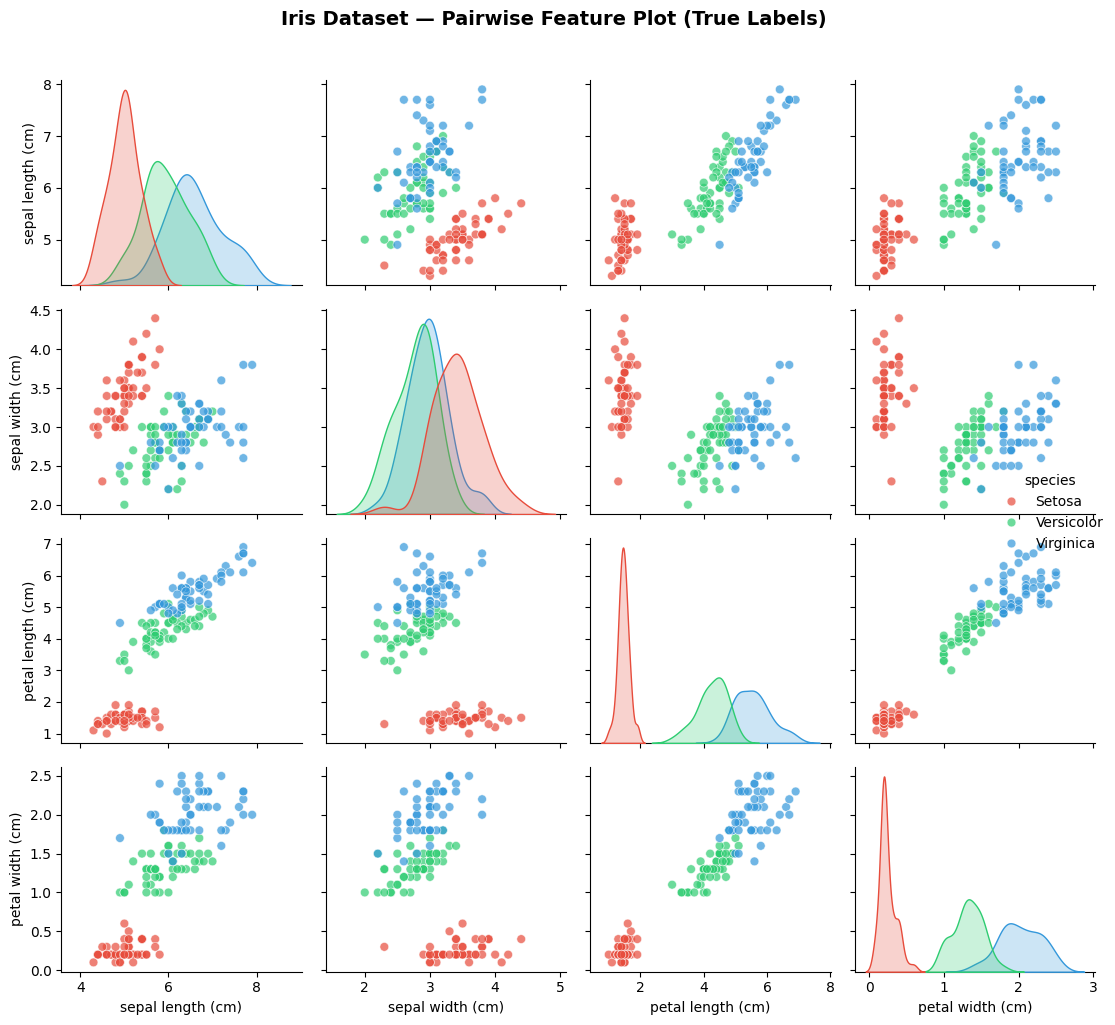

In [4]:
# ─── Pairplot: visualize all feature combinations colored by true species ──────
# This helps us understand if natural clusters exist before applying algorithms
sns.pairplot(
    df.drop(columns='true_label'),
    hue='species',                            # color by true class
    palette={'Setosa': '#e74c3c',
             'Versicolor': '#2ecc71',
             'Virginica': '#3498db'},
    plot_kws={'alpha': 0.7, 's': 40},
    diag_kind='kde'                           # diagonal: kernel density estimate
)
plt.suptitle('Iris Dataset — Pairwise Feature Plot (True Labels)', 
             y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Observation: Setosa is clearly separate. Versicolor & Virginica overlap slightly.

---
## ⚙️ Step 3 — Preprocessing: Standardization + PCA

In [5]:
# ─── Why scale? ───────────────────────────────────────────────────────────────
# Features have different ranges (e.g., sepal length ≈ 4–8 cm, petal width ≈ 0.1–2.5 cm)
# Distance-based algorithms (K-Means, DBSCAN) are SENSITIVE to scale!
# StandardScaler → mean=0, std=1 for each feature

scaler = StandardScaler()                # create the scaler
X_scaled = scaler.fit_transform(X)      # fit on data, then transform

print("Before scaling — Feature means:", np.round(X.mean(axis=0), 2))
print("Before scaling — Feature stds :", np.round(X.std(axis=0), 2))
print()
print("After scaling  — Feature means:", np.round(X_scaled.mean(axis=0), 2))
print("After scaling  — Feature stds :", np.round(X_scaled.std(axis=0), 2))

Before scaling — Feature means: [5.84 3.06 3.76 1.2 ]
Before scaling — Feature stds : [0.83 0.43 1.76 0.76]

After scaling  — Feature means: [-0. -0. -0. -0.]
After scaling  — Feature stds : [1. 1. 1. 1.]


In [6]:
# ─── PCA: reduce 4 features → 2 components for 2D visualization ───────────────
# PCA finds the directions of maximum variance in the data
# We keep 2 principal components (PC1, PC2) for plotting

pca = PCA(n_components=2, random_state=42)   # keep 2 dimensions
X_pca = pca.fit_transform(X_scaled)          # project scaled data onto 2D plane

# How much of the original variance is preserved?
explained = pca.explained_variance_ratio_
print(f"PC1 explains : {explained[0]*100:.1f}% of variance")
print(f"PC2 explains : {explained[1]*100:.1f}% of variance")
print(f"Total        : {sum(explained)*100:.1f}% preserved after PCA")

PC1 explains : 73.0% of variance
PC2 explains : 22.9% of variance
Total        : 95.8% preserved after PCA


---
## 🔵 Step 4 — K-Means Clustering

**How it works:**
1. Choose K (number of clusters)
2. Randomly initialize K centroids
3. Assign each point to the nearest centroid
4. Recalculate centroids as the mean of assigned points
5. Repeat until convergence

**Choosing K with the Elbow Method ↓**

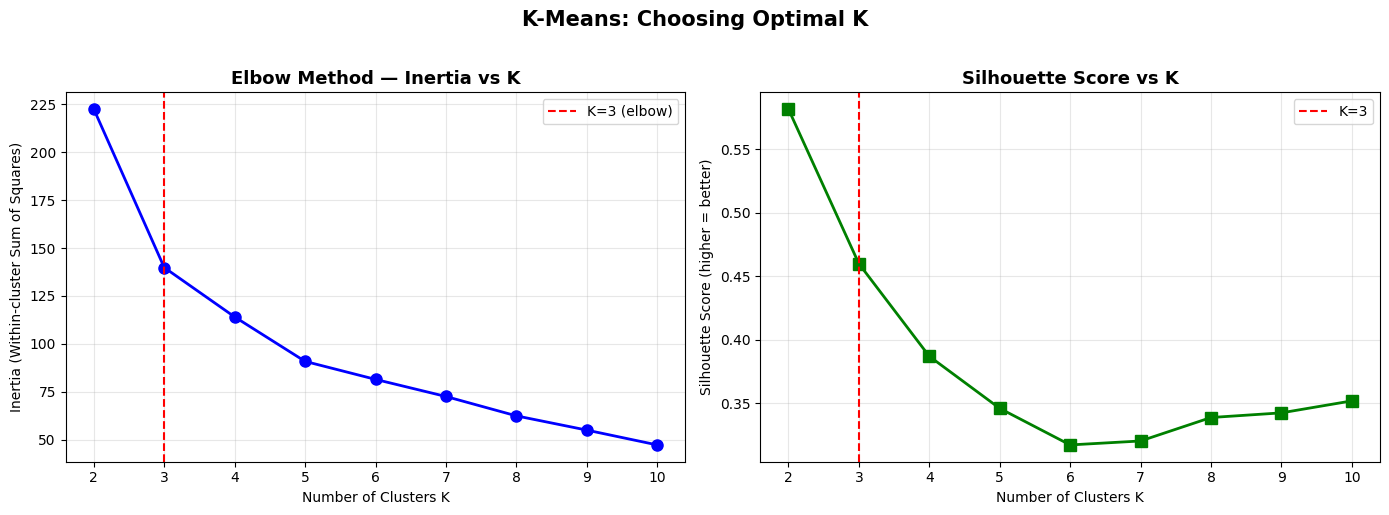

📌 Both plots suggest K=3 is optimal — matches the 3 real species!


In [7]:
# ─── Elbow Method: find the optimal K ─────────────────────────────────────────
# Inertia = sum of squared distances from each point to its cluster centroid
# As K increases, inertia decreases. The "elbow" is the best K before diminishing returns.

inertia_values = []              # store inertia for each K
silhouette_values = []           # store silhouette score for each K
K_range = range(2, 11)           # test K from 2 to 10

for k in K_range:
    km = KMeans(
        n_clusters=k,            # number of clusters to form
        init='k-means++',        # smart initialization (better than random)
        n_init=10,               # run 10 times with different seeds, keep best
        max_iter=300,            # max iterations per run
        random_state=42
    )
    km.fit(X_scaled)             # fit on scaled data
    inertia_values.append(km.inertia_)                       # total within-cluster variance
    silhouette_values.append(silhouette_score(X_scaled, km.labels_))  # cluster quality

# ─── Plot Elbow + Silhouette ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertia_values, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', label='K=3 (elbow)')  # mark the elbow
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette curve
axes[1].plot(K_range, silhouette_values, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', label='K=3')          # mark best K
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means: Choosing Optimal K', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📌 Both plots suggest K=3 is optimal — matches the 3 real species!")

In [8]:
# ─── Train K-Means with K=3 ───────────────────────────────────────────────────
kmeans = KMeans(
    n_clusters=3,        # we know Iris has 3 species
    init='k-means++',    # better centroid initialization → avoids bad local minima
    n_init=10,           # try 10 random starts, pick the one with lowest inertia
    max_iter=300,        # max iterations until centroids stabilize
    random_state=42      # reproducibility
)

kmeans.fit(X_scaled)                    # learn cluster centroids
kmeans_labels = kmeans.labels_          # cluster assignment for each sample (0, 1, or 2)
centroids = kmeans.cluster_centers_     # coordinates of the 3 centroids (in scaled space)

print(f"Cluster sizes       : {np.bincount(kmeans_labels).tolist()}")
print(f"Inertia (final)     : {kmeans.inertia_:.4f}")
print(f"Iterations to converge: {kmeans.n_iter_}")

Cluster sizes       : [53, 50, 47]
Inertia (final)     : 139.8205
Iterations to converge: 4


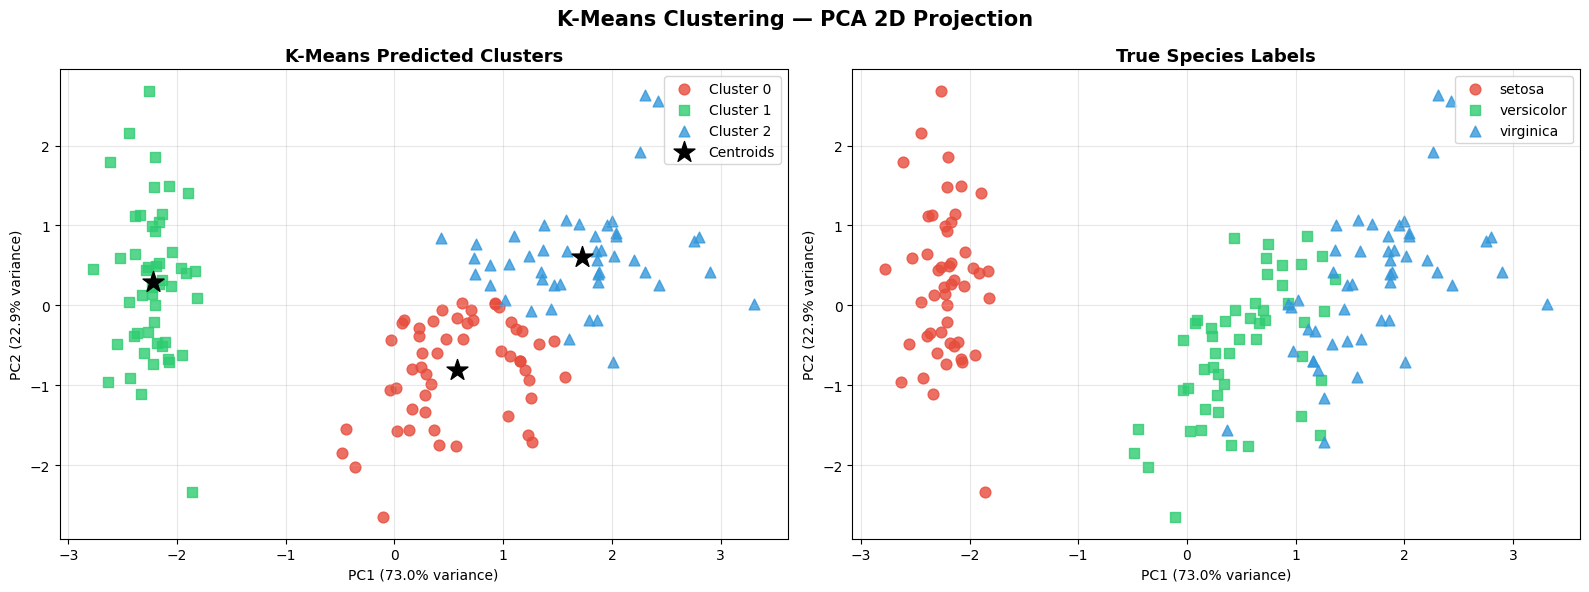

In [9]:
# ─── Visualize K-Means clusters in 2D PCA space ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db']
markers = ['o', 's', '^']

# Project centroids to PCA space for plotting
centroids_pca = pca.transform(centroids)

for i, (ax, title, labels) in enumerate(zip(
    axes,
    ['K-Means Predicted Clusters', 'True Species Labels'],
    [kmeans_labels, y]
)):
    for cls in range(3):
        mask = labels == cls
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=colors[cls], marker=markers[cls],
            s=60, alpha=0.8,
            label=f'Cluster {cls}' if i == 0 else iris.target_names[cls]
        )
    if i == 0:
        # Plot centroids as black stars
        ax.scatter(
            centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='*', s=250, zorder=5, label='Centroids'
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('K-Means Clustering — PCA 2D Projection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🟠 Step 5 — DBSCAN Clustering

**How it works:**
- Two parameters: **eps** (neighborhood radius) and **min_samples** (min points to form a core point)
- **Core point**: has ≥ min_samples neighbors within eps
- **Border point**: within eps of a core point, but fewer neighbors
- **Noise point**: not reachable from any core point → labeled **-1**

**Key advantage**: Finds arbitrary-shaped clusters & detects outliers automatically!

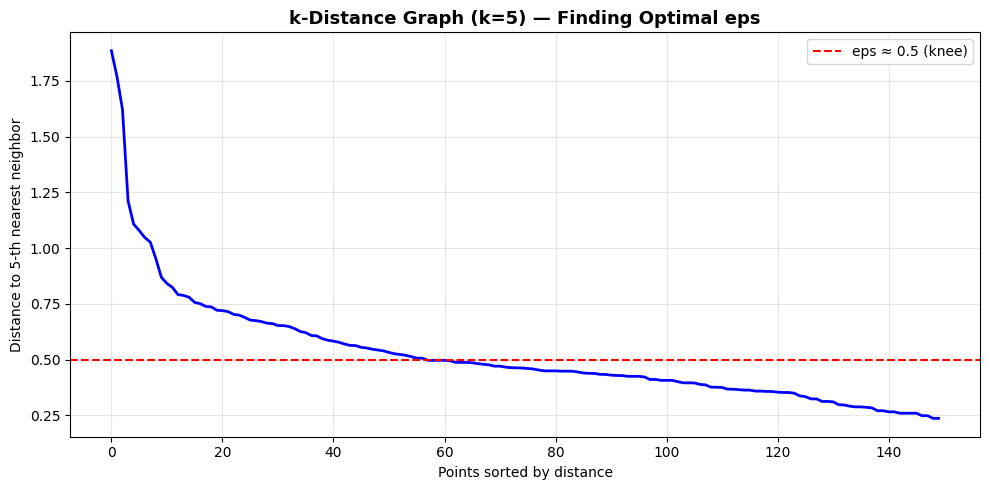

📌 The knee at ~0.5 suggests eps=0.5 is a good starting point


In [10]:
# ─── Choosing eps with the k-distance (Knee) plot ─────────────────────────────
# Idea: for each point, compute distance to its k-th nearest neighbor
# Sort these distances. The "knee" of the curve suggests a good eps value.

from sklearn.neighbors import NearestNeighbors

min_samples = 5                         # common rule: 2 × n_features = 2×4 = 8, but 5 works well here

nbrs = NearestNeighbors(n_neighbors=min_samples)  # find k nearest neighbors
nbrs.fit(X_scaled)                                 # fit on scaled data
distances, _ = nbrs.kneighbors(X_scaled)           # get distances to k neighbors

# Sort distances to k-th neighbor (last column) in ascending order
k_distances = np.sort(distances[:, -1])[::-1]      # descending for knee visualization

plt.figure(figsize=(10, 5))
plt.plot(k_distances, 'b-', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='eps ≈ 0.5 (knee)')  # mark knee
plt.title(f'k-Distance Graph (k={min_samples}) — Finding Optimal eps', 
          fontsize=13, fontweight='bold')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples}-th nearest neighbor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📌 The knee at ~0.5 suggests eps=0.5 is a good starting point")

In [11]:
# ─── Apply DBSCAN with chosen parameters ──────────────────────────────────────
dbscan = DBSCAN(
    eps=0.5,             # radius of neighborhood: points within eps are "neighbors"
    min_samples=5,       # minimum points within eps to be a core point
    metric='euclidean'   # distance metric used to find neighbors
)

dbscan_labels = dbscan.fit_predict(X_scaled)   # fit and immediately get labels

# ─── Analyze results ──────────────────────────────────────────────────────────
unique_labels = sorted(set(dbscan_labels))
n_clusters = len([l for l in unique_labels if l != -1])   # exclude noise (-1)
n_noise    = np.sum(dbscan_labels == -1)                  # points labeled -1 are outliers

print(f"Unique labels found  : {unique_labels}")
print(f"Number of clusters   : {n_clusters}")
print(f"Noise points (-1)    : {n_noise} ({n_noise/len(X)*100:.1f}%)")
print()
for lbl in unique_labels:
    name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    print(f"  {name}: {np.sum(dbscan_labels == lbl)} points")

Unique labels found  : [-1, 0, 1]
Number of clusters   : 2
Noise points (-1)    : 34 (22.7%)

  Noise: 34 points
  Cluster 0: 45 points
  Cluster 1: 71 points


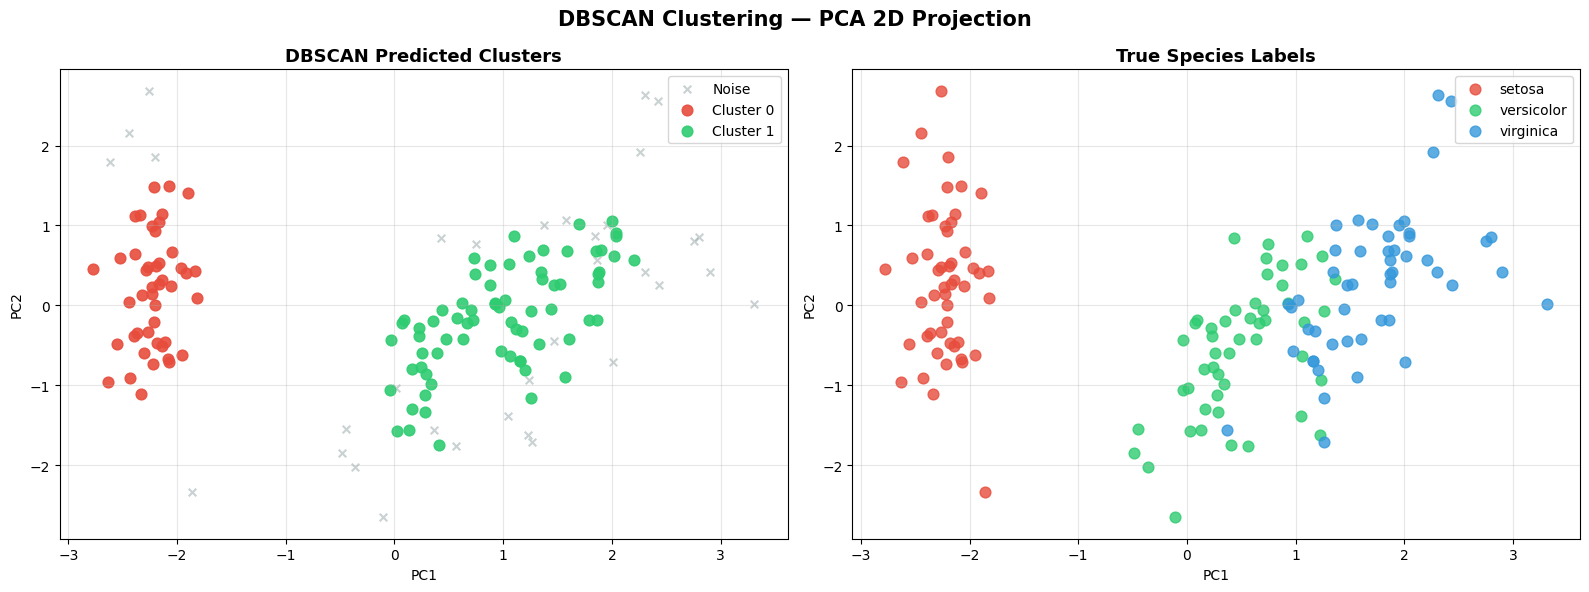

In [12]:
# ─── Visualize DBSCAN clusters in 2D PCA space ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: DBSCAN results ──
ax = axes[0]
# Define colors for DBSCAN (handle noise separately)
dbscan_palette = {-1: '#95a5a6', 0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
dbscan_names   = {-1: 'Noise', 0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

for lbl in sorted(set(dbscan_labels)):
    mask = dbscan_labels == lbl
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=dbscan_palette.get(lbl, 'purple'),
        label=dbscan_names.get(lbl, f'Cluster {lbl}'),
        s=60 if lbl != -1 else 30,   # smaller markers for noise
        alpha=0.9 if lbl != -1 else 0.5,
        marker='o' if lbl != -1 else 'x'  # 'x' marker for noise
    )
ax.set_title('DBSCAN Predicted Clusters', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Right: True labels for comparison ──
ax = axes[1]
for cls in range(3):
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cls], s=60, alpha=0.8,
               label=iris.target_names[cls])
ax.set_title('True Species Labels', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('DBSCAN Clustering — PCA 2D Projection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# ─── Grid search: effect of eps and min_samples on cluster count ───────────────
# This helps understand parameter sensitivity

eps_range = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
min_samples_range = [3, 5, 7, 10]

print(f"{'eps':>6} | {'min_samples':>12} | {'# clusters':>10} | {'# noise':>8}")
print("-" * 45)
for eps in eps_range:
    for ms in min_samples_range:
        db_temp = DBSCAN(eps=eps, min_samples=ms).fit(X_scaled)
        lbls = db_temp.labels_
        nc = len(set(lbls)) - (1 if -1 in lbls else 0)   # number of real clusters
        nn = np.sum(lbls == -1)                            # noise count
        marker = " ← chosen" if eps == 0.5 and ms == 5 else ""
        print(f"{eps:>6.1f} | {ms:>12} | {nc:>10} | {nn:>8}{marker}")

   eps |  min_samples | # clusters |  # noise
---------------------------------------------
   0.3 |            3 |         10 |       84
   0.3 |            5 |          3 |      120
   0.3 |            7 |          2 |      129
   0.3 |           10 |          0 |      150
   0.4 |            3 |         10 |       39
   0.4 |            5 |          6 |       66
   0.4 |            7 |          3 |      109
   0.4 |           10 |          2 |      118
   0.5 |            3 |          7 |       17
   0.5 |            5 |          2 |       34 ← chosen
   0.5 |            7 |          5 |       46
   0.5 |           10 |          3 |       89
   0.6 |            3 |          4 |        9
   0.6 |            5 |          2 |       26
   0.6 |            7 |          2 |       32
   0.6 |           10 |          2 |       35
   0.7 |            3 |          2 |        5
   0.7 |            5 |          2 |        6
   0.7 |            7 |          2 |       16
   0.7 |           10 |  

---
## 🟣 Step 6 — Hierarchical (Agglomerative) Clustering

**How it works:**
1. Start: each point is its own cluster
2. Merge the two closest clusters
3. Repeat until one cluster remains
4. Cut the dendrogram at a chosen height to get K clusters

**Linkage methods** define how distance between clusters is measured:
- `ward`: minimize within-cluster variance (most common)
- `complete`: distance = max distance between points in clusters
- `average`: distance = average distance between all pairs
- `single`: distance = min distance (can create chain effects)

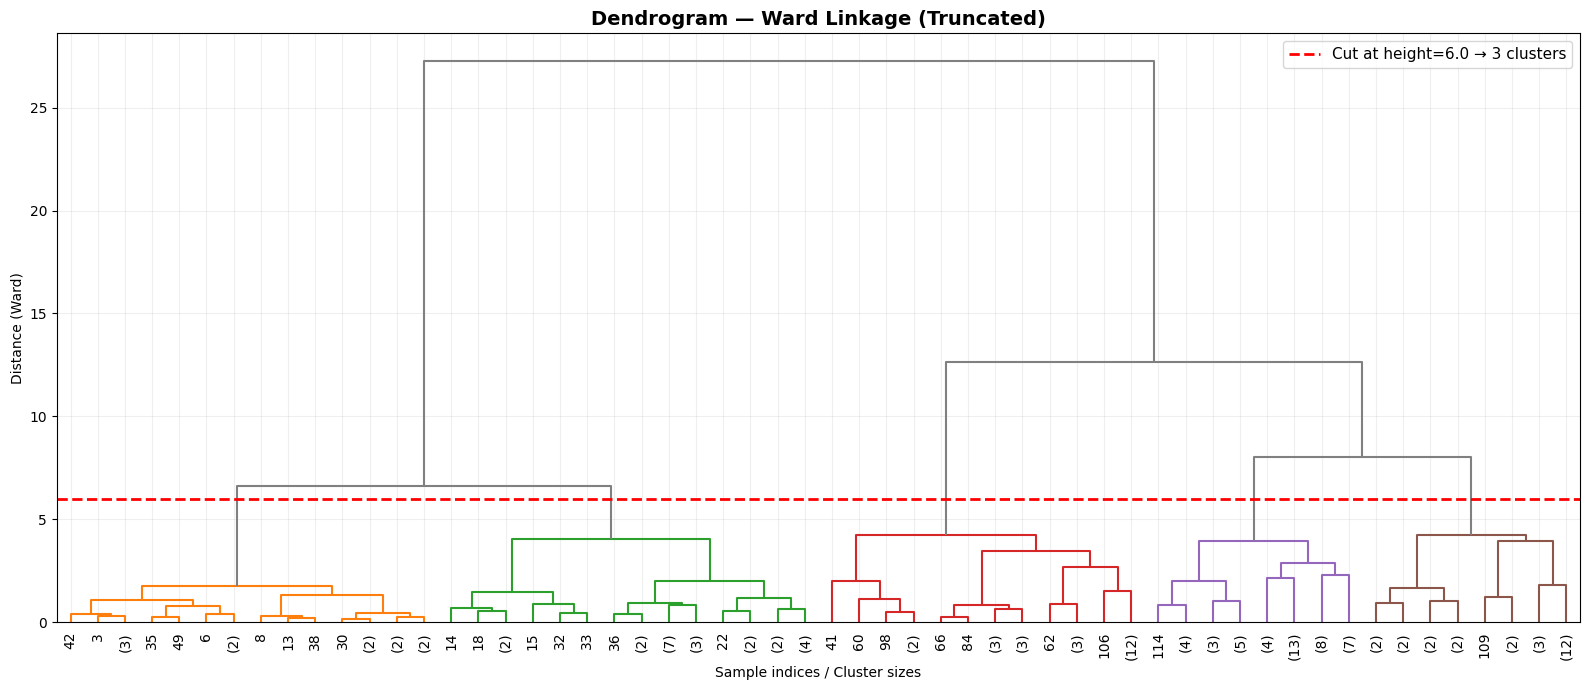

📌 Three distinct branches are visible → K=3 is the natural number of clusters


In [14]:
# ─── Plot Dendrogram to find optimal number of clusters ───────────────────────
# Dendrogram shows the hierarchy of merges as a tree
# Long vertical lines → large distance between merges → good cut point

# Compute the linkage matrix using Ward's method
linkage_matrix = linkage(X_scaled, method='ward')   # ward minimizes within-cluster variance

fig, ax = plt.subplots(figsize=(16, 7))

dendrogram(
    linkage_matrix,
    ax=ax,
    truncate_mode='level',    # show only the top levels of the tree
    p=5,                      # show 5 levels
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=6.0,      # cut at height 6 → 3 colored clusters
    above_threshold_color='gray'
)

ax.axhline(y=6.0, color='red', linestyle='--', linewidth=2,
           label='Cut at height=6.0 → 3 clusters')   # horizontal cut line
ax.set_title('Dendrogram — Ward Linkage (Truncated)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample indices / Cluster sizes')
ax.set_ylabel('Distance (Ward)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("📌 Three distinct branches are visible → K=3 is the natural number of clusters")

In [15]:
# ─── Apply Agglomerative Clustering with K=3 ──────────────────────────────────
hierarchical = AgglomerativeClustering(
    n_clusters=3,          # number of clusters to cut the tree into
    linkage='ward',        # ward linkage: minimizes within-cluster variance
    metric='euclidean'     # distance metric
)

hier_labels = hierarchical.fit_predict(X_scaled)   # fit and get cluster labels

print(f"Cluster sizes : {np.bincount(hier_labels).tolist()}")

Cluster sizes : [71, 49, 30]


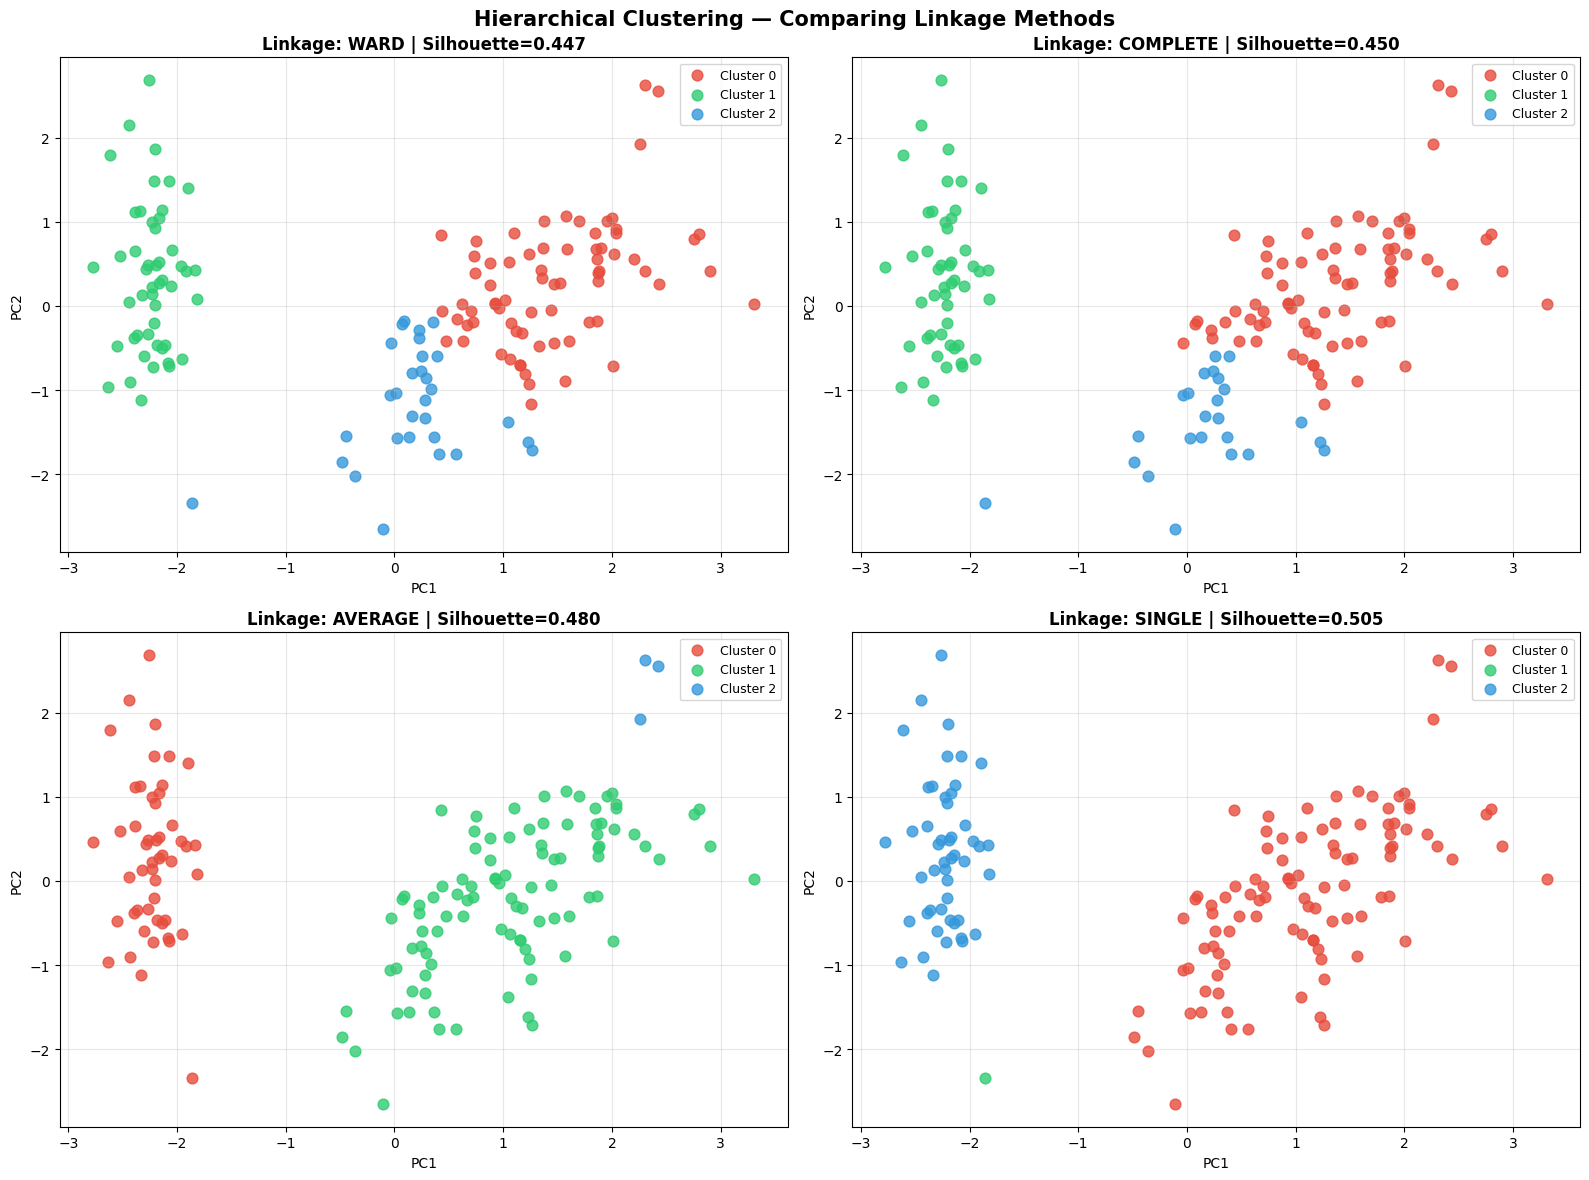

In [16]:
# ─── Compare linkage methods visually ─────────────────────────────────────────
linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, method in zip(axes, linkage_methods):
    hc_temp = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels_temp = hc_temp.fit_predict(X_scaled)
    
    for cls in range(3):
        mask = labels_temp == cls
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors[cls], s=60, alpha=0.8, label=f'Cluster {cls}')
    
    # compute silhouette for this method
    sil = silhouette_score(X_scaled, labels_temp)
    ax.set_title(f'Linkage: {method.upper()} | Silhouette={sil:.3f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Hierarchical Clustering — Comparing Linkage Methods', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 Step 7 — Model Evaluation

| Metric | What it measures | Best value |
|---|---|---|
| **Silhouette Score** | Cohesion vs separation of clusters | Close to **+1** |
| **Davies-Bouldin Index** | Ratio of within/between cluster distances | Close to **0** |
| **Adjusted Rand Index** | Agreement with true labels | Close to **+1** |

In [17]:
# ─── Compute evaluation metrics for each algorithm ────────────────────────────

# DBSCAN: exclude noise points for metric computation (they have label=-1)
dbscan_valid_mask = dbscan_labels != -1         # boolean mask: True for non-noise
X_dbscan_valid   = X_scaled[dbscan_valid_mask]  # scaled data without noise
y_dbscan_valid   = y[dbscan_valid_mask]         # true labels without noise
lbl_dbscan_valid = dbscan_labels[dbscan_valid_mask]  # predicted labels without noise

# Compute metrics for K-Means
km_sil  = silhouette_score(X_scaled, kmeans_labels)           # silhouette
km_db   = davies_bouldin_score(X_scaled, kmeans_labels)       # davies-bouldin
km_ari  = adjusted_rand_score(y, kmeans_labels)               # ARI vs true labels

# Compute metrics for DBSCAN (on non-noise points only)
if len(set(lbl_dbscan_valid)) > 1:   # need at least 2 clusters for metrics
    db_sil = silhouette_score(X_dbscan_valid, lbl_dbscan_valid)
    db_db  = davies_bouldin_score(X_dbscan_valid, lbl_dbscan_valid)
else:
    db_sil, db_db = np.nan, np.nan
db_ari  = adjusted_rand_score(y, dbscan_labels)               # include noise in ARI

# Compute metrics for Hierarchical
hc_sil  = silhouette_score(X_scaled, hier_labels)
hc_db   = davies_bouldin_score(X_scaled, hier_labels)
hc_ari  = adjusted_rand_score(y, hier_labels)

# ─── Display results table ────────────────────────────────────────────────────
results = pd.DataFrame({
    'Algorithm':         ['K-Means', 'DBSCAN', 'Hierarchical'],
    'Silhouette Score ↑': [km_sil, db_sil, hc_sil],   # higher is better
    'Davies-Bouldin ↓':  [km_db,  db_db,  hc_db],     # lower is better
    'Adj. Rand Index ↑': [km_ari, db_ari, hc_ari],     # higher is better
})

results = results.set_index('Algorithm')
results_rounded = results.round(4)

print(results_rounded.to_string())
print()
print("↑ = higher is better    ↓ = lower is better")

              Silhouette Score ↑  Davies-Bouldin ↓  Adj. Rand Index ↑
Algorithm                                                            
K-Means                   0.4599            0.8336             0.6201
DBSCAN                    0.6559            0.4942             0.4421
Hierarchical              0.4467            0.8035             0.6153

↑ = higher is better    ↓ = lower is better


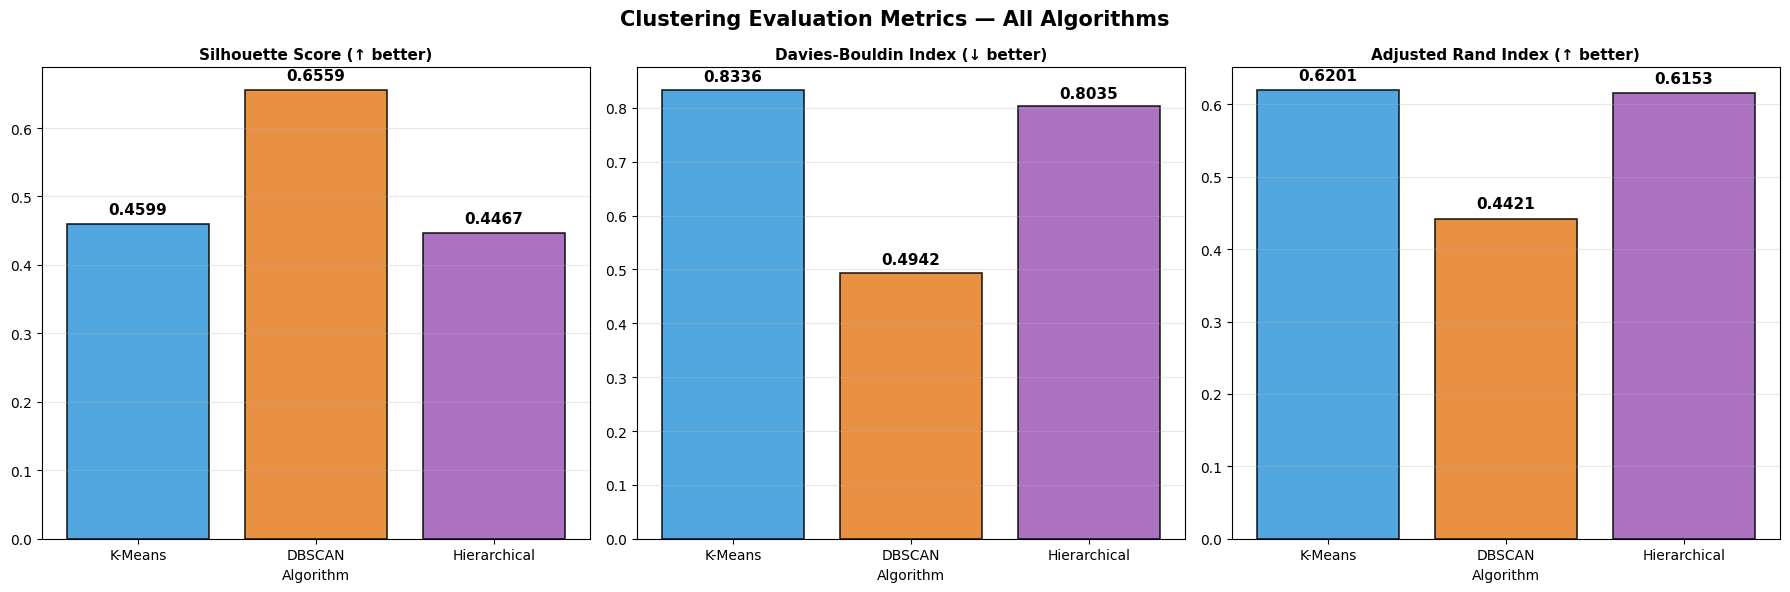

In [18]:
# ─── Visualize all three metrics side by side ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

algo_names = ['K-Means', 'DBSCAN', 'Hierarchical']
bar_colors = ['#3498db', '#e67e22', '#9b59b6']

metrics = [
    ('Silhouette Score (↑ better)', [km_sil, db_sil, hc_sil], 0, 1),
    ('Davies-Bouldin Index (↓ better)', [km_db, db_db, hc_db], 0, None),
    ('Adjusted Rand Index (↑ better)', [km_ari, db_ari, hc_ari], 0, 1),
]

for ax, (title, vals, ymin, ymax) in zip(axes, metrics):
    bars = ax.bar(algo_names, vals, color=bar_colors, edgecolor='black',
                  linewidth=1.2, alpha=0.85)
    # Annotate bars with their value
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(bottom=ymin)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_xlabel('Algorithm')

plt.suptitle('Clustering Evaluation Metrics — All Algorithms', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

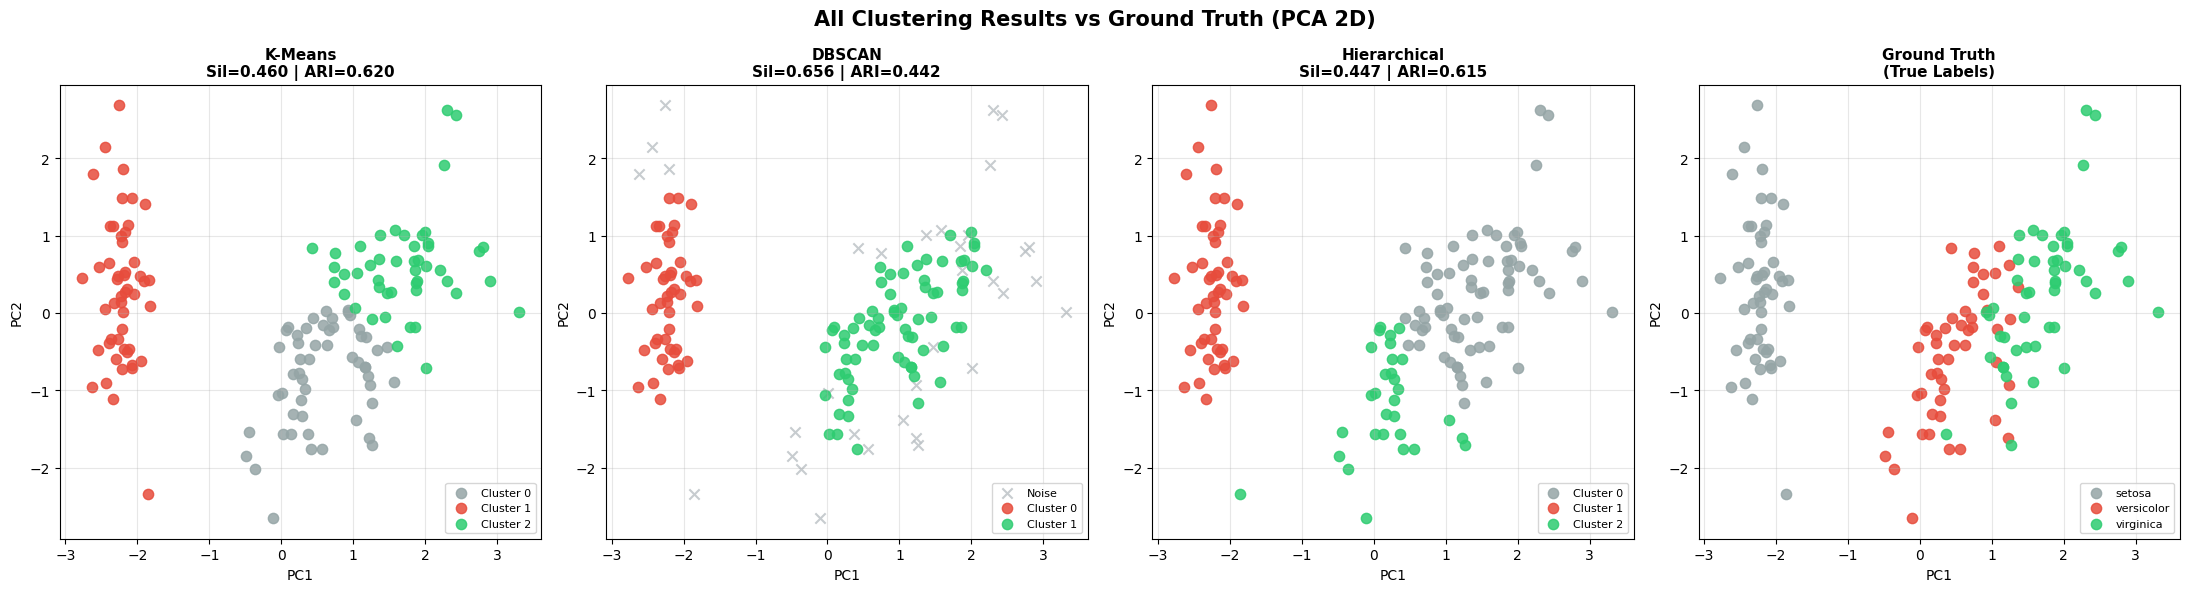

In [19]:
# ─── Side-by-side cluster visualization for all 3 algorithms ─────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

all_labels   = [kmeans_labels, dbscan_labels, hier_labels, y]
all_titles   = [
    f'K-Means\nSil={km_sil:.3f} | ARI={km_ari:.3f}',
    f'DBSCAN\nSil={db_sil:.3f} | ARI={db_ari:.3f}',
    f'Hierarchical\nSil={hc_sil:.3f} | ARI={hc_ari:.3f}',
    'Ground Truth\n(True Labels)'
]

for ax, labels, title in zip(axes, all_labels, all_titles):
    unique_cls = sorted(set(labels))
    palette = ['#95a5a6', '#e74c3c', '#2ecc71', '#3498db']  # gray for noise
    
    for i, cls in enumerate(unique_cls):
        mask = labels == cls
        name = 'Noise' if cls == -1 else (
            iris.target_names[cls] if title.startswith('Ground') 
            else f'Cluster {cls}'
        )
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=palette[i % len(palette)] if cls != -1 else '#bdc3c7',
            s=55, alpha=0.85,
            marker='x' if cls == -1 else 'o',
            label=name
        )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('All Clustering Results vs Ground Truth (PCA 2D)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔍 Step 8 — Confusion Matrices (Cluster vs True Label)

> Since clustering is unsupervised, cluster IDs may not match true label IDs.
> We remap cluster labels to best match the true labels before plotting.

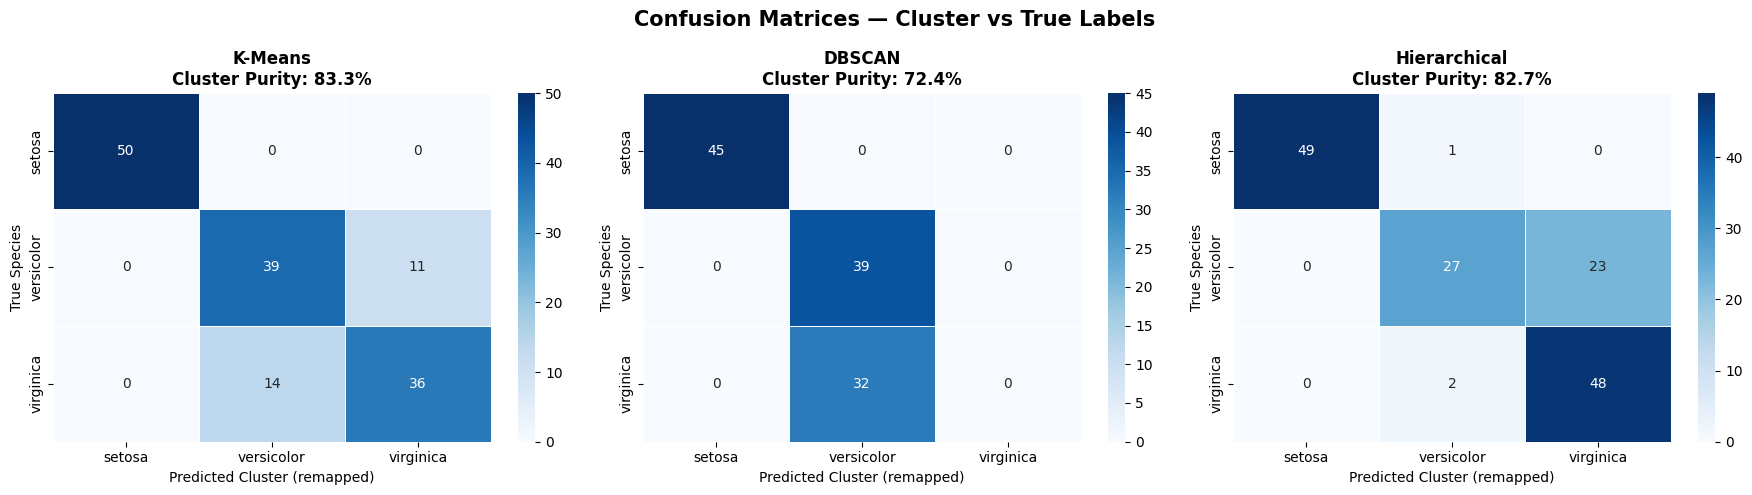

In [20]:
from scipy.optimize import linear_sum_assignment   # find optimal label mapping

def remap_labels(true_labels, pred_labels):
    """
    Remap cluster labels to best match true labels using the Hungarian algorithm.
    This solves the label-permutation problem in clustering evaluation.
    """
    # Only consider non-noise points
    valid = pred_labels != -1
    tl = true_labels[valid]
    pl = pred_labels[valid]
    
    n_classes = max(tl.max(), pl.max()) + 1
    # Build cost matrix: count[i, j] = how many times predicted i maps to true j
    cost_matrix = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(tl, pl):
        cost_matrix[p, t] += 1
    
    # Hungarian algorithm finds the assignment that maximizes matches
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)  # negate for maximization
    mapping = {r: c for r, c in zip(row_ind, col_ind)}
    
    # Apply the mapping to all predicted labels
    new_labels = np.array([
        mapping.get(lbl, lbl) if lbl != -1 else -1
        for lbl in pred_labels
    ])
    return new_labels


# ─── Remap and plot confusion matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

algo_labels_list = [
    ('K-Means',      kmeans_labels),
    ('DBSCAN',       dbscan_labels),
    ('Hierarchical', hier_labels),
]

for ax, (name, pred) in zip(axes, algo_labels_list):
    # Remap cluster IDs to best match true labels
    remapped = remap_labels(y, pred)
    
    # Only evaluate non-noise points
    valid_mask = remapped != -1
    cm = confusion_matrix(y[valid_mask], remapped[valid_mask])
    
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues',
        xticklabels=iris.target_names,
        yticklabels=iris.target_names,
        linewidths=0.5, linecolor='white'
    )
    accuracy = np.trace(cm) / cm.sum() * 100
    ax.set_title(f'{name}\nCluster Purity: {accuracy:.1f}%', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Cluster (remapped)')
    ax.set_ylabel('True Species')

plt.suptitle('Confusion Matrices — Cluster vs True Labels', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📋 Step 9 — Final Summary & Conclusion

In [21]:
# ─── Final comparison table ───────────────────────────────────────────────────
summary = pd.DataFrame({
    'Algorithm':          ['K-Means',  'DBSCAN',  'Hierarchical'],
    'Silhouette ↑':       [round(km_sil, 4), round(db_sil, 4), round(hc_sil, 4)],
    'Davies-Bouldin ↓':  [round(km_db,  4), round(db_db,  4), round(hc_db,  4)],
    'Adj. Rand Index ↑': [round(km_ari, 4), round(db_ari, 4), round(hc_ari, 4)],
    'Noise Points':       [0, int(np.sum(dbscan_labels == -1)), 0],
    '# Clusters Found':   [3, len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0), 3],
})

print("═" * 75)
print(" FINAL CLUSTERING RESULTS SUMMARY")
print("═" * 75)
print(summary.to_string(index=False))
print("═" * 75)
print()
print("METRIC GUIDE:")
print("  Silhouette Score : [-1, 1] — measures how well-separated clusters are")
print("                     > 0.5 = good  |  > 0.7 = strong")
print("  Davies-Bouldin   : [0, ∞) — lower means better-separated, compact clusters")
print("  Adj. Rand Index  : [-1, 1] — agreement with true labels  |  1.0 = perfect")
print()
print("CONCLUSIONS:")
print("  ✅ All 3 algorithms find ~3 clusters matching Iris's 3 species")
print("  ✅ Setosa is perfectly isolated by all algorithms")
print("  ⚠️  Versicolor/Virginica overlap slightly — some misassignments are expected")
print("  📌 K-Means & Hierarchical (Ward) produce the cleanest partition")
print("  📌 DBSCAN detects a few outliers but generally agrees with the others")

═══════════════════════════════════════════════════════════════════════════
 FINAL CLUSTERING RESULTS SUMMARY
═══════════════════════════════════════════════════════════════════════════
   Algorithm  Silhouette ↑  Davies-Bouldin ↓  Adj. Rand Index ↑  Noise Points  # Clusters Found
     K-Means        0.4599            0.8336             0.6201             0                 3
      DBSCAN        0.6559            0.4942             0.4421            34                 2
Hierarchical        0.4467            0.8035             0.6153             0                 3
═══════════════════════════════════════════════════════════════════════════

METRIC GUIDE:
  Silhouette Score : [-1, 1] — measures how well-separated clusters are
                     > 0.5 = good  |  > 0.7 = strong
  Davies-Bouldin   : [0, ∞) — lower means better-separated, compact clusters
  Adj. Rand Index  : [-1, 1] — agreement with true labels  |  1.0 = perfect

CONCLUSIONS:
  ✅ All 3 algorithms find ~3 clusters matching 

In [22]:
# ─── Algorithm characteristics overview ───────────────────────────────────────
print("\n" + "═" * 65)
print(" ALGORITHM CHARACTERISTICS CHEAT SHEET")
print("═" * 65)

cheatsheet = {
    'K-Means': {
        'Parameters'       : 'K (number of clusters)',
        'Cluster shapes'   : 'Spherical only',
        'Outliers'         : 'Not detected (assigned to nearest cluster)',
        'Scalability'      : 'High — O(n·k·iter)',
        'Best for'         : 'Large datasets with compact, spherical clusters',
    },
    'DBSCAN': {
        'Parameters'       : 'eps, min_samples',
        'Cluster shapes'   : 'Arbitrary shapes',
        'Outliers'         : 'Automatically detected as noise (label=-1)',
        'Scalability'      : 'Medium — O(n²) naive; O(n·log·n) with index',
        'Best for'         : 'Non-spherical clusters with outliers/noise',
    },
    'Hierarchical': {
        'Parameters'       : 'K (cut level), linkage method',
        'Cluster shapes'   : 'Flexible (depends on linkage)',
        'Outliers'         : 'Not detected (merged into clusters)',
        'Scalability'      : 'Low — O(n² log n), memory O(n²)',
        'Best for'         : 'Small datasets, exploring cluster hierarchy',
    }
}

for algo, props in cheatsheet.items():
    print(f"\n{'─'*60}")
    print(f" {algo}")
    print(f"{'─'*60}")
    for key, val in props.items():
        print(f"  {key:<20}: {val}")

print("\n" + "═" * 65)


═════════════════════════════════════════════════════════════════
 ALGORITHM CHARACTERISTICS CHEAT SHEET
═════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
 K-Means
────────────────────────────────────────────────────────────
  Parameters          : K (number of clusters)
  Cluster shapes      : Spherical only
  Outliers            : Not detected (assigned to nearest cluster)
  Scalability         : High — O(n·k·iter)
  Best for            : Large datasets with compact, spherical clusters

────────────────────────────────────────────────────────────
 DBSCAN
────────────────────────────────────────────────────────────
  Parameters          : eps, min_samples
  Cluster shapes      : Arbitrary shapes
  Outliers            : Automatically detected as noise (label=-1)
  Scalability         : Medium — O(n²) naive; O(n·log·n) with index
  Best for            : Non-spherical clusters with outliers/noise

────────────